In [1]:
import torch
import numpy as np

In [2]:
file_name = "/Users/sayan/personal/sayan_github/dl-lecture-notes/docs/neural_network_and_deep_learning/rnn/data/input.txt"


In [8]:
# data I/O
data = open(file_name, 'r').read()
chars = list(set(data))
data_size, vocab_size = len(data), len(chars)
print(f'data has {data_size} characters, {vocab_size} unique.')
char_to_ix = { ch:i for i,ch in enumerate(chars) }
ix_to_char = { i:ch for i,ch in enumerate(chars) }


data has 1115394 characters, 65 unique.


In [9]:
# hyperparameters
hidden_size = 100 # size of hidden layer of neurons
seq_length = 25 # number of steps to unroll the RNN for
learning_rate = 1e-1

# model parameters
Wxh = np.random.randn(hidden_size, vocab_size)*0.01 # input to hidden
Whh = np.random.randn(hidden_size, hidden_size)*0.01 # hidden to hidden
Why = np.random.randn(vocab_size, hidden_size)*0.01 # hidden to output
bh = np.zeros((hidden_size, 1)) # hidden bias
by = np.zeros((vocab_size, 1)) # output bias

In [10]:
my_test = {}
type(my_test)

dict

In [20]:
linear_layer_1 = torch.nn.Linear(4,3)
for name, v in linear_layer_1.named_parameters():
    print(name,v)
    print(v.shape)

weight Parameter containing:
tensor([[-0.3600, -0.4717, -0.4435,  0.4761],
        [ 0.1459,  0.0818,  0.2433, -0.1609],
        [ 0.2457,  0.1844,  0.0354,  0.4800]], requires_grad=True)
torch.Size([3, 4])
bias Parameter containing:
tensor([ 0.2351, -0.1275,  0.4702], requires_grad=True)
torch.Size([3])


In [25]:
torch.rand(3,1).T @ linear_layer_1.weight 

tensor([[ 0.1020, -0.0508, -0.0655,  0.5761]], grad_fn=<MmBackward0>)

In [16]:
N = 100 # number of points per class
D = 2 # dimensionality
K = 3 # number of classes
X = np.zeros((N*K,D)) # data matrix (each row = single example)
y = np.zeros(N*K, dtype='uint8') # class labels
for j in range(K):
  ix = range(N*j,N*(j+1))
  r = np.linspace(0.0,1,N) # radius
  t = np.linspace(j*4,(j+1)*4,N) + np.random.randn(N)*0.2 # theta
  X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
  y[ix] = j
# lets visualize the data:


In [19]:
X.shape, y.shape

((300, 2), (300,))

In [30]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris

In [33]:
iris_data = load_iris(as_frame=True)
iris_data.keys()


dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [37]:
iris_data['data']

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [38]:
?train_test_split

Signature:
train_test_split(
    *arrays,
    test_size=None,
    train_size=None,
    random_state=None,
    shuffle=True,
    stratify=None,
)
Docstring:
Split arrays or matrices into random train and test subsets.

Quick utility that wraps input validation,
``next(ShuffleSplit().split(X, y))``, and application to input data
into a single call for splitting (and optionally subsampling) data into a
one-liner.

Read more in the :ref:`User Guide <cross_validation>`.

Parameters
----------
*arrays : sequence of indexables with same length / shape[0]
    Allowed inputs are lists, numpy arrays, scipy-sparse
    matrices or pandas dataframes.

test_size : float or int, default=None
    If float, should be between 0.0 and 1.0 and represent the proportion
    of the dataset to include in the test split. If int, represents the
    absolute number of test samples. If None, the value is set to the
    complement of the train size. If ``train_size`` is also None, it will
    be set to 0.25.

trai

In [39]:
from sklearn.linear_model import LogisticRegression


In [40]:
?LogisticRegression

Init signature:
LogisticRegression(
    penalty='l2',
    *,
    dual=False,
    tol=0.0001,
    C=1.0,
    fit_intercept=True,
    intercept_scaling=1,
    class_weight=None,
    random_state=None,
    solver='lbfgs',
    max_iter=100,
    multi_class='deprecated',
    verbose=0,
    warm_start=False,
    n_jobs=None,
    l1_ratio=None,
)
Docstring:     
Logistic Regression (aka logit, MaxEnt) classifier.

In the multiclass case, the training algorithm uses the one-vs-rest (OvR)
scheme if the 'multi_class' option is set to 'ovr', and uses the
cross-entropy loss if the 'multi_class' option is set to 'multinomial'.
(Currently the 'multinomial' option is supported only by the 'lbfgs',
'sag', 'saga' and 'newton-cg' solvers.)

This class implements regularized logistic regression using the
'liblinear' library, 'newton-cg', 'sag', 'saga' and 'lbfgs' solvers. **Note
that regularization is applied by default**. It can handle both dense
and sparse input. Use C-ordered arrays or CSR matrices co

In [41]:
X, y = load_iris(return_X_y=True)

In [48]:
#y
from sklearn.datasets import make_friedman3

In [49]:
?make_friedman3

Signature: make_friedman3(n_samples=100, *, noise=0.0, random_state=None)
Docstring:
Generate the "Friedman #3" regression problem.

This dataset is described in Friedman [1] and Breiman [2].

Inputs `X` are 4 independent features uniformly distributed on the
intervals::

    0 <= X[:, 0] <= 100,
    40 * pi <= X[:, 1] <= 560 * pi,
    0 <= X[:, 2] <= 1,
    1 <= X[:, 3] <= 11.

The output `y` is created according to the formula::

    y(X) = arctan((X[:, 1] * X[:, 2] - 1 / (X[:, 1] * X[:, 3])) / X[:, 0]) + noise * N(0, 1).

Read more in the :ref:`User Guide <sample_generators>`.

Parameters
----------
n_samples : int, default=100
    The number of samples.

noise : float, default=0.0
    The standard deviation of the gaussian noise applied to the output.

random_state : int, RandomState instance or None, default=None
    Determines random number generation for dataset noise. Pass an int
    for reproducible output across multiple function calls.
    See :term:`Glossary <random_state>`

In [51]:
from torch.optim import AdamW
?AdamW

Init signature:
AdamW(
    params: Union[Iterable[torch.Tensor], Iterable[Dict[str, Any]]],
    lr: Union[float, torch.Tensor] = 0.001,
    betas: Tuple[float, float] = (0.9, 0.999),
    eps: float = 1e-08,
    weight_decay: float = 0.01,
    amsgrad: bool = False,
    *,
    maximize: bool = False,
    foreach: Optional[bool] = None,
    capturable: bool = False,
    differentiable: bool = False,
    fused: Optional[bool] = None,
)
Docstring:     
Implements AdamW algorithm.

.. math::
   \begin{aligned}
        &\rule{110mm}{0.4pt}                                                                 \\
        &\textbf{input}      : \gamma \text{(lr)}, \: \beta_1, \beta_2
            \text{(betas)}, \: \theta_0 \text{(params)}, \: f(\theta) \text{(objective)},
            \: \epsilon \text{ (epsilon)}                                                    \\
        &\hspace{13mm}      \lambda \text{(weight decay)},  \: \textit{amsgrad},
            \: \textit{maximize}                       

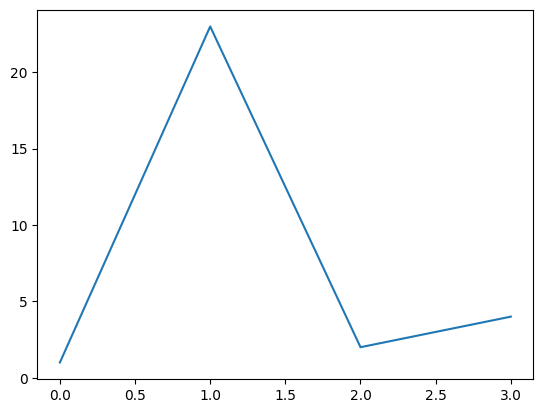

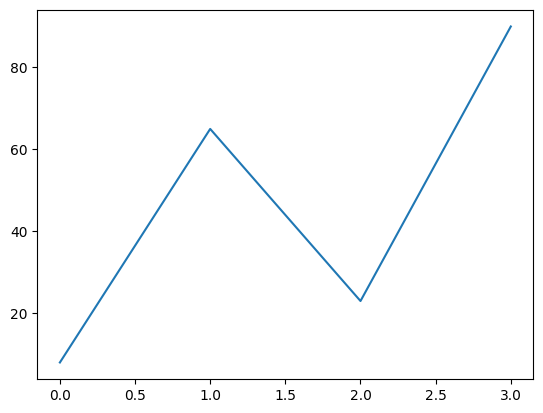

In [53]:
#| layout-ncol: 2
#| fig-cap: 
#|   - "Line Plot 1"
#|   - "Line Plot 2"

import matplotlib.pyplot as plt
plt.plot([1,23,2,4])
plt.show()

plt.plot([8,65,23,90])
plt.show()


In [54]:
import torch.nn as nn

In [56]:
rnn = nn.LSTM(10, 20, 2)
input = torch.randn(5, 3, 10)
h0 = torch.randn(2, 3, 20)
c0 = torch.randn(2, 3, 20)
output, (hn, cn) = rnn(input, (h0, c0))

In [58]:
#output

In [60]:
rnn_names = []
for n, p in rnn.named_parameters():
    rnn_names.append(n)
    #print(f"n:{n}, p:{p}")

In [61]:
rnn_names

['weight_ih_l0',
 'weight_hh_l0',
 'bias_ih_l0',
 'bias_hh_l0',
 'weight_ih_l1',
 'weight_hh_l1',
 'bias_ih_l1',
 'bias_hh_l1']

In [62]:
tessaaaaaaaaafgz = nn.LSTMCell(10, 20)
lstm_names = []
for n, p in test.named_parameters():
    lstm_names.append(n)

In [63]:
lstm_names

['weight_ih', 'weight_hh', 'bias_ih', 'bias_hh']

In [64]:
linear_layer = nn.Linear(5,3)

In [66]:
linear_layer.bias

Parameter containing:
tensor([ 0.3019, -0.1440,  0.0632], requires_grad=True)